# Task 5: Data Visualization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file_path = "../data/phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx"

state_txn_users = pd.read_excel(file_path, sheet_name="State_Txn and Users")
state_txn_split = pd.read_excel(file_path, sheet_name="State_TxnSplit")
district_demo = pd.read_excel(file_path, sheet_name="District Demographics")

print("Datasets loaded successfully!")

Datasets loaded successfully!


## Task 5.1: Plot the total transactions and amount over time for a selected state

In [3]:
selected_state = "Uttar Pradesh"

state_data = state_txn_users[state_txn_users["State"] == selected_state]

state_time_data = (
    state_data
    .groupby(["Year", "Quarter"])[["Transactions", "Amount (INR)"]]
    .sum()
    .reset_index()
)

state_time_data

,Year,Quarter,Transactions,Amount (INR)
0,2018,1,12537805,1.393997e+10
1,2018,2,17710943,2.572020e+10
2,2018,3,26515356,3.701211e+10
3,2018,4,36100767,5.509674e+10
4,2019,1,57324504,7.652418e+10
5,2019,2,58883500,9.891752e+10
6,2019,3,68623959,1.112681e+11
7,2019,4,86905005,1.455389e+11
8,2020,1,97239132,1.724164e+11
9,2020,2,100851965,1.787440e+11


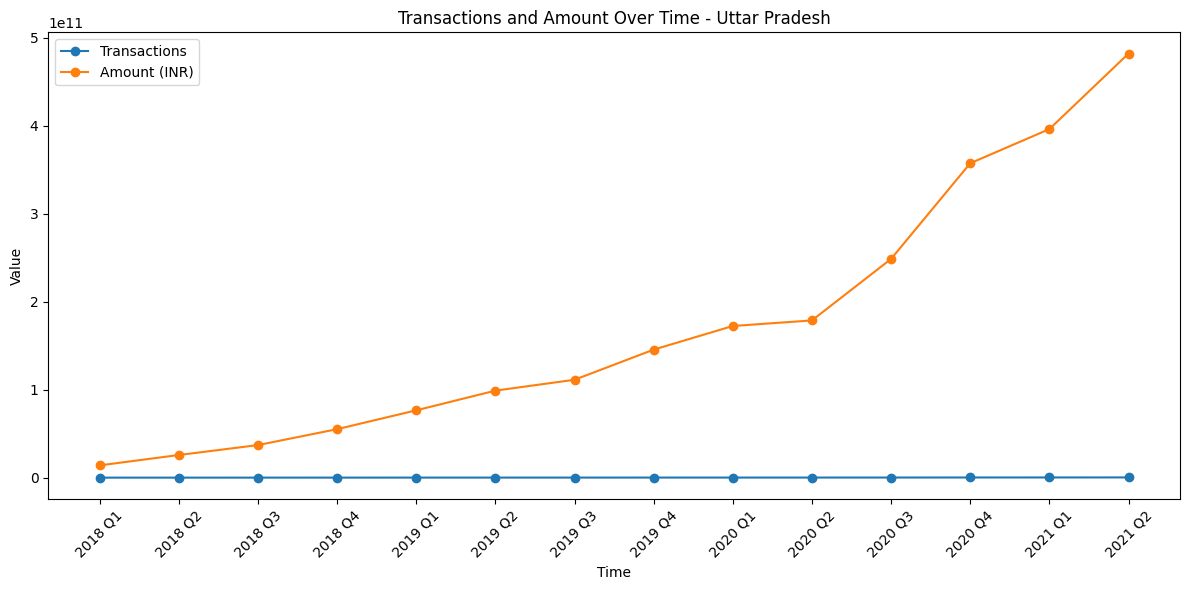

In [4]:
state_time_data["Time"] = (
    state_time_data["Year"].astype(str) + " Q" + state_time_data["Quarter"].astype(str)
)

plt.figure(figsize=(12, 6))

plt.plot(state_time_data["Time"], state_time_data["Transactions"], marker="o", label="Transactions")
plt.plot(state_time_data["Time"], state_time_data["Amount (INR)"], marker="o", label="Amount (INR)")

plt.title(f"Transactions and Amount Over Time - {selected_state}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Task 5.2: Create a pie chart showing the distribution of transaction types for a specific quarter

In [5]:
selected_state = "Uttar Pradesh"
selected_year = state_txn_split["Year"].max()
selected_quarter = state_txn_split[state_txn_split["Year"] == selected_year]["Quarter"].max()

quarter_data = state_txn_split[
    (state_txn_split["State"] == selected_state) &
    (state_txn_split["Year"] == selected_year) &
    (state_txn_split["Quarter"] == selected_quarter)
]

quarter_data

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2439,Uttar Pradesh,2021,2,Peer-to-peer payments,102927942,3.887618e+11,3777.028983
2440,Uttar Pradesh,2021,2,Merchant payments,84860582,7.035140e+10,829.023317
2441,Uttar Pradesh,2021,2,Recharge & bill payments,53030710,2.226693e+10,419.887404
2442,Uttar Pradesh,2021,2,Financial Services,270944,2.668531e+08,984.901186
2443,Uttar Pradesh,2021,2,Others,858953,5.254877e+08,611.776992


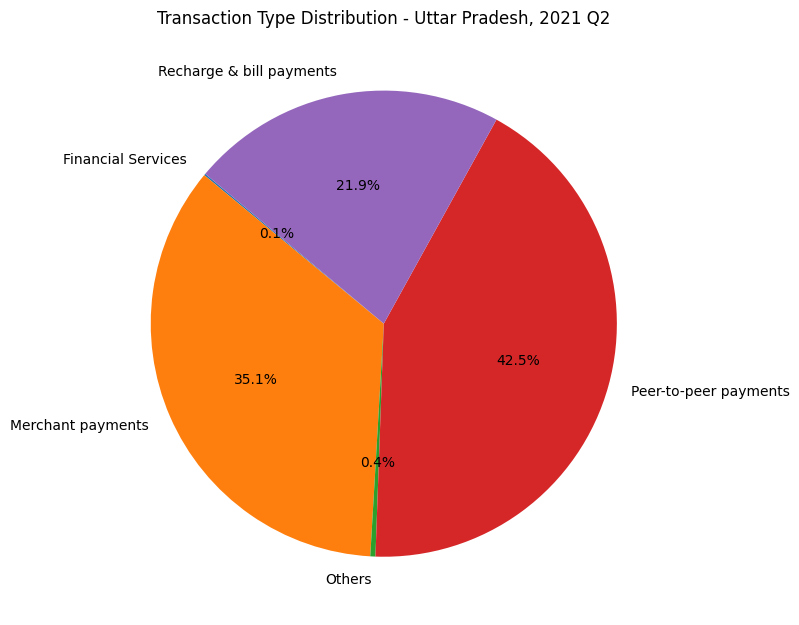

In [6]:
transaction_type_distribution = (
    quarter_data
    .groupby("Transaction Type")["Transactions"]
    .sum()
)

plt.figure(figsize=(8, 8))

plt.pie(
    transaction_type_distribution,
    labels=transaction_type_distribution.index,
    autopct="%1.1f%%",
    startangle=140
)

plt.title(f"Transaction Type Distribution - {selected_state}, {selected_year} Q{selected_quarter}")
plt.tight_layout()
plt.show()

## Task 5.3: Visualize the population density of districts in a selected state

In [7]:
selected_state = "Uttar Pradesh"

state_density_data = district_demo[district_demo["State"] == selected_state][["District", "Density"]]

state_density_data = state_density_data.sort_values(by="Density", ascending=False)

state_density_data

,District,Density
616,Ghaziabad,3967
660,Varanasi,2399
621,Hapur,2028
635,Lucknow,1815
602,Bhadohi,1531
...,...,...
607,Chitrakoot,315
637,Mahoba,288
657,Sonbhadra,274
620,Hamirpur,268


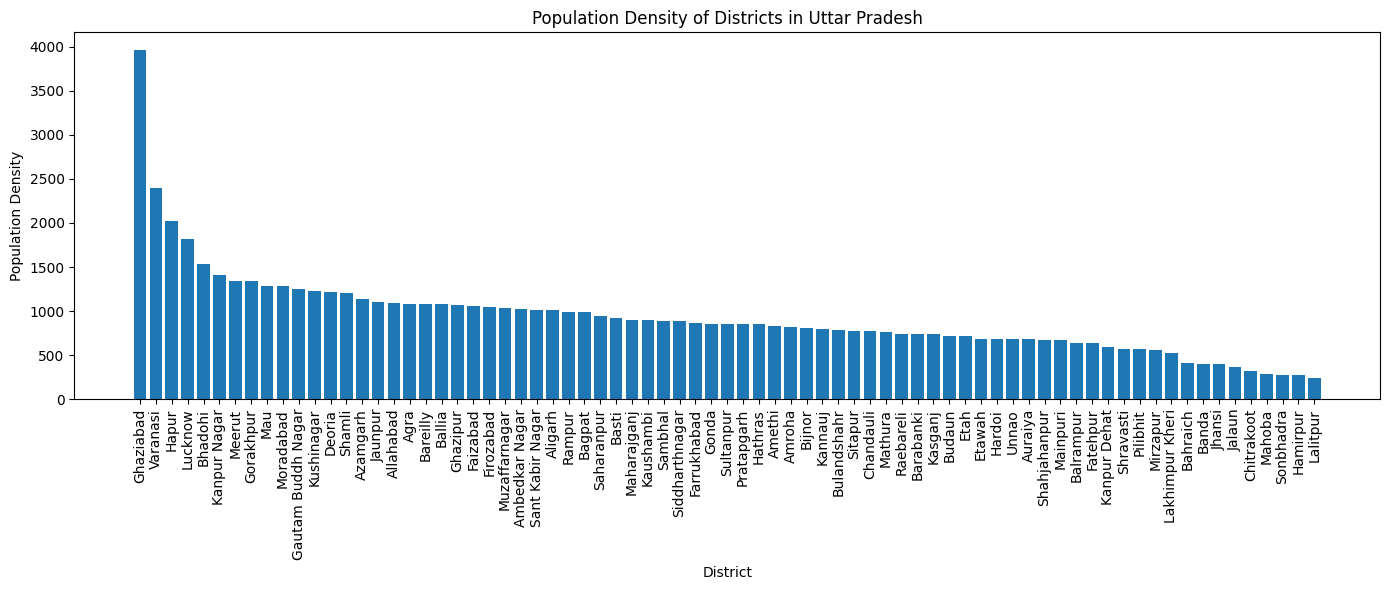

In [8]:
plt.figure(figsize=(14, 6))

plt.bar(state_density_data["District"], state_density_data["Density"])

plt.title(f"Population Density of Districts in {selected_state}")
plt.xlabel("District")
plt.ylabel("Population Density")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Conclusion

Task 5 completed successfully.

- Plotted transactions and amount over time for a selected state.
- Created a pie chart for transaction type distribution.
- Visualized district population density for a selected state.